# Permian–Waha Basis Analysis

Joins Henry Hub (FRED, daily) and Waha Hub (EIA Weekly Update, regex-parsed) into a single
basis series, flags unusually wide/narrow weeks, and produces the chart + summary stats for
the README's "Key findings" section.

**Scope note:** Waha coverage runs 2022-01-01 through 2026-01-21 only — EIA discontinued the
report this project parses after that date. See README section 6 for the full explanation.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"

pd.set_option("display.max_rows", 20)


## 1. Load the two raw series

In [2]:
henry_hub = pd.read_csv(f"{RAW_DIR}/henry_hub_daily_fred.csv", parse_dates=["date"])
waha = pd.read_csv(f"{RAW_DIR}/waha_weekly_parsed.csv", parse_dates=["report_date"])

print(f"Henry Hub: {len(henry_hub)} daily rows, {henry_hub['date'].min().date()} to {henry_hub['date'].max().date()}")
print(f"Waha: {len(waha)} weekly rows parsed, {waha['waha_price'].notna().sum()} with a usable price")

waha = waha.dropna(subset=["waha_price"]).copy()
waha.head()


Henry Hub: 5687 daily rows, 1997-01-07 to 2026-09-15
Waha: 196 weekly rows parsed, 111 with a usable price


,report_date,waha_price,basis_vs_henry_hub,total_rig_count,oil_rigs,gas_rigs
0,2022-01-05,3.76,NaN,NaN,NaN,NaN
1,2022-01-12,4.11,NaN,NaN,NaN,NaN
2,2022-01-19,4.69,NaN,NaN,NaN,NaN
3,2022-01-26,4.04,NaN,NaN,NaN,NaN
4,2022-02-02,7.26,NaN,NaN,NaN,NaN


## 2. Join on the report date

Each Waha figure is described in its source report as the price "yesterday" relative to the
Thursday release — i.e. the Wednesday the report week ends on. `report_date` in the parsed CSV
is already that Wednesday, so join directly against Henry Hub's daily price on the same date.

In [3]:
df = waha.merge(
    henry_hub.rename(columns={"date": "report_date"}),
    on="report_date",
    how="left",
)

missing_hh = df["henry_hub_price"].isna().sum()
if missing_hh:
    print(f"Warning: {missing_hh} weeks have no matching Henry Hub price on that exact date "
          f"(likely a market holiday) — dropping them.")
    df = df.dropna(subset=["henry_hub_price"])

df = df.sort_values("report_date").reset_index(drop=True)
df.head()


,report_date,waha_price,basis_vs_henry_hub,total_rig_count,oil_rigs,gas_rigs,henry_hub_price
0,2022-01-05,3.76,NaN,NaN,NaN,NaN,3.78
1,2022-01-12,4.11,NaN,NaN,NaN,NaN,4.62
2,2022-01-19,4.69,NaN,NaN,NaN,NaN,4.89
3,2022-01-26,4.04,NaN,NaN,NaN,NaN,4.43
4,2022-02-02,7.26,NaN,NaN,NaN,NaN,6.70


## 3. Compute the basis

Basis = Waha price − Henry Hub price. Negative means Waha traded below Henry Hub (the normal,
expected direction given Permian takeaway constraints).

We also have `basis_vs_henry_hub` already extracted from EIA's own explicit "traded $X below
the Henry Hub price" sentences where that sentence existed — use it as a sanity check against
our own calculation.

In [4]:
df["basis_calculated"] = df["waha_price"] - df["henry_hub_price"]

# Sanity check against EIA's own stated basis figure, where we have one
check = df.dropna(subset=["basis_vs_henry_hub"]).copy()
check["diff"] = (check["basis_calculated"] - check["basis_vs_henry_hub"]).abs()
print(f"{len(check)} weeks have both a calculated and an EIA-stated basis to compare.")
print(f"Median absolute difference: {check['diff'].median():.3f} $/MMBtu")
print(f"Max absolute difference: {check['diff'].max():.3f} $/MMBtu")
# Small differences are expected (Henry Hub daily close timing vs. the "yesterday" EIA quotes,
# different reporting sources for Waha). Large differences (>$0.50) are worth spot-checking.
check.nlargest(5, "diff")[["report_date", "waha_price", "henry_hub_price", "basis_calculated", "basis_vs_henry_hub", "diff"]]


34 weeks have both a calculated and an EIA-stated basis to compare.
Median absolute difference: 0.035 $/MMBtu
Max absolute difference: 3.600 $/MMBtu


,report_date,waha_price,henry_hub_price,basis_calculated,basis_vs_henry_hub,diff
95,2025-03-12,4.00,4.18,-0.18,-3.78,3.60
83,2024-10-09,2.10,2.43,-0.33,-3.58,3.25
84,2024-10-16,2.08,2.21,-0.13,-3.04,2.91
66,2024-04-17,1.46,1.50,-0.04,-2.68,2.64
75,2024-07-31,2.30,1.94,0.36,-2.15,2.51


## 4. Flag unusually wide/narrow weeks

Rolling mean/std over a trailing window, flagging weeks where basis is more than N standard
deviations from the trailing norm. Window is in **observations**, not weeks — since there are
real gaps in Waha coverage, a 12-observation window can span a much longer wall-clock period
during sparse stretches. Worth keeping in mind when reading the flagged dates.

In [5]:
ROLLING_WINDOW = 12  # observations, not weeks — see note above
N_STD = 2

df["rolling_mean"] = df["basis_calculated"].rolling(ROLLING_WINDOW, min_periods=6).mean()
df["rolling_std"] = df["basis_calculated"].rolling(ROLLING_WINDOW, min_periods=6).std()
df["z_score"] = (df["basis_calculated"] - df["rolling_mean"]) / df["rolling_std"]
df["flagged"] = df["z_score"].abs() > N_STD

print(f"{df['flagged'].sum()} of {len(df)} weeks flagged as unusual (|z| > {N_STD})")
df[df["flagged"]][["report_date", "waha_price", "henry_hub_price", "basis_calculated", "z_score"]]


9 of 111 weeks flagged as unusual (|z| > 2)


,report_date,waha_price,henry_hub_price,basis_calculated,z_score
28,2022-08-24,8.08,9.27,-1.19,-2.031342
29,2022-09-14,7.24,8.70,-1.46,-2.118750
30,2022-09-21,5.09,7.99,-2.90,-2.801945
35,2022-10-26,-0.65,5.28,-5.93,-2.622823
53,2023-10-25,0.39,2.86,-2.47,-2.723205
55,2023-12-13,3.39,2.33,1.06,2.230688
77,2024-08-28,-3.67,1.89,-5.56,-2.575769
91,2024-12-18,5.02,3.01,2.01,2.292295
96,2025-03-19,-0.57,4.21,-4.78,-2.046567


## 5. Plot

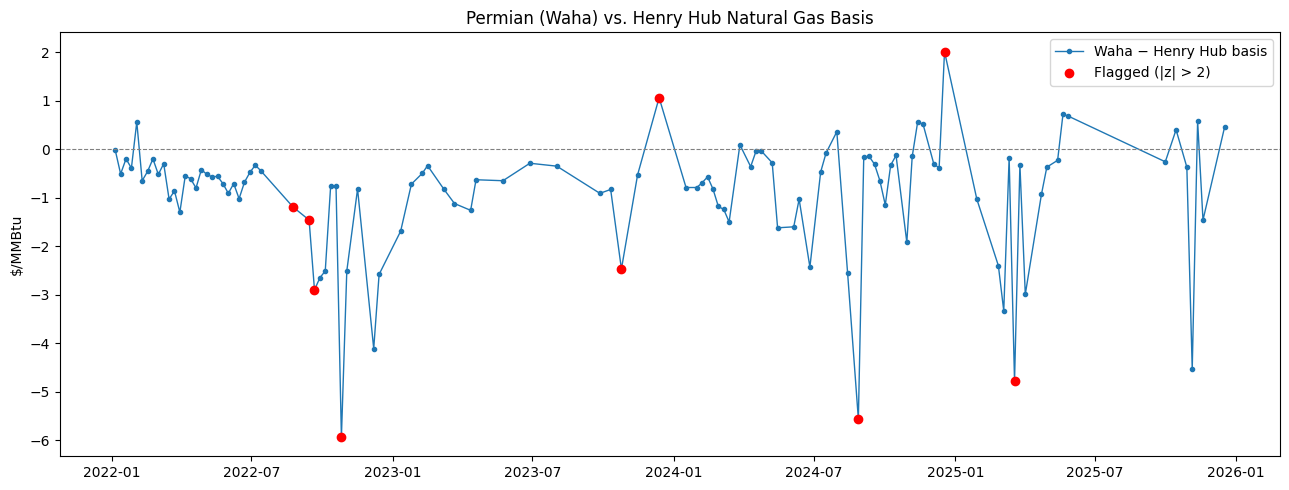

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df["report_date"], df["basis_calculated"], marker="o", markersize=3, linewidth=1, label="Waha − Henry Hub basis")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

flagged = df[df["flagged"]]
ax.scatter(flagged["report_date"], flagged["basis_calculated"], color="red", zorder=5, label=f"Flagged (|z| > {N_STD})")

ax.set_title("Permian (Waha) vs. Henry Hub Natural Gas Basis")
ax.set_ylabel("$/MMBtu")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/basis_chart.png", dpi=150)
plt.show()


## 6. Summary stats for the README's Key Findings section

In [7]:
print("Basis summary stats ($/MMBtu):")
print(df["basis_calculated"].describe())
print()
print(f"Weeks with negative basis (Waha below Henry Hub): "
      f"{(df['basis_calculated'] < 0).sum()} of {len(df)} "
      f"({(df['basis_calculated'] < 0).mean():.0%})")
print()
widest = df.nsmallest(5, "basis_calculated")[["report_date", "waha_price", "henry_hub_price", "basis_calculated"]]
print("5 widest (most negative) basis weeks:")
widest


Basis summary stats ($/MMBtu):
count    111.000000
mean      -0.914685
std        1.251074
min       -5.930000
25%       -1.165000
50%       -0.630000
75%       -0.300000
max        2.010000
Name: basis_calculated, dtype: float64

Weeks with negative basis (Waha below Henry Hub): 99 of 111 (89%)

5 widest (most negative) basis weeks:


,report_date,waha_price,henry_hub_price,basis_calculated
35,2022-10-26,-0.65,5.28,-5.93
77,2024-08-28,-3.67,1.89,-5.56
96,2025-03-19,-0.57,4.21,-4.78
107,2025-11-05,-1.02,3.51,-4.53
38,2022-12-07,0.38,4.49,-4.11


In [8]:
df.to_csv(f"{PROCESSED_DIR}/basis_table.csv", index=False)
print(f"Saved {len(df)} rows to {PROCESSED_DIR}/basis_table.csv")


Saved 111 rows to ../data/processed/basis_table.csv


## 7. Enrichment: storage and rig count

Two additional series, both parsed/pulled separately:
- **South Central regional gas storage** (EIA API, `duoarea=R33`, `process=SWO` — the total
  working-gas figure for the region containing Texas, not the Lower 48 aggregate).
- **Rig counts** (oil/gas, Baker Hughes-sourced), already present as columns in `waha` from the
  same pages the Waha price was parsed from.

**Alignment note:** EIA's storage report covers weeks ending Friday, but the Waha/Henry Hub
basis data is keyed on Wednesday (`report_date`). These don't share a calendar day, so a plain
merge on date would silently produce all-NaN storage. Instead we use `merge_asof` to attach each
Wednesday to the most recent Friday storage figure that had already been published by then.

In [9]:
storage = pd.read_csv(f"{RAW_DIR}/storage_weekly_south_central.csv", parse_dates=["period"])
storage = storage[["period", "value"]].rename(columns={"period": "storage_date", "value": "storage_bcf"})
storage = storage.sort_values("storage_date").reset_index(drop=True)

print(f"Storage: {len(storage)} weekly rows, {storage['storage_date'].min().date()} to {storage['storage_date'].max().date()}")
storage.head()


Storage: 873 weekly rows, 2010-01-01 to 2026-09-18


,storage_date,storage_bcf
0,2010-01-01,985
1,2010-01-08,886
2,2010-01-15,793
3,2010-01-22,789
4,2010-01-29,779


In [10]:
# merge_asof requires both frames sorted on the join key, and matches each basis week to the
# most recent storage report AT OR BEFORE that date (direction="backward") — i.e. the last
# storage figure that would actually have been known as of that Wednesday.
df_enriched = pd.merge_asof(
    df.sort_values("report_date"),
    storage,
    left_on="report_date",
    right_on="storage_date",
    direction="backward",
)

gap_days = (df_enriched["report_date"] - df_enriched["storage_date"]).dt.days
print(f"Median days between basis week and the storage figure it's matched to: {gap_days.median():.0f}")
print(f"Max gap: {gap_days.max()} days — large gaps usually mean a stretch of missing storage reports, worth spot-checking.")

df_enriched[["report_date", "storage_date", "storage_bcf", "basis_calculated", "total_rig_count"]].head()


Median days between basis week and the storage figure it's matched to: 5
Max gap: 5 days — large gaps usually mean a stretch of missing storage reports, worth spot-checking.


,report_date,storage_date,storage_bcf,basis_calculated,total_rig_count
0,2022-01-05,2021-12-31,1143,-0.02,NaN
1,2022-01-12,2022-01-07,1088,-0.51,NaN
2,2022-01-19,2022-01-14,1019,-0.20,NaN
3,2022-01-26,2022-01-21,938,-0.39,NaN
4,2022-02-02,2022-01-28,837,0.56,NaN


## 8. Does storage or rig count help explain the basis — or predict it?

Two separate questions worth keeping distinct:
1. **Same-week correlation** — does the basis level relate to storage/rig levels *at the same time*?
   This tells us about a relationship, not a forecast.
2. **Leading-indicator check** — does storage or rig count from N weeks *earlier* correlate with
   this week's basis? This is the actually decision-useful version, since it's what you'd know
   in advance.

In [11]:
corr_cols = ["basis_calculated", "storage_bcf", "total_rig_count", "gas_rigs"]
available = [c for c in corr_cols if df_enriched[c].notna().sum() > 10]
print(f"Same-week correlation (pairwise, using available overlapping data):")
df_enriched[available].corr()


Same-week correlation (pairwise, using available overlapping data):


,basis_calculated,storage_bcf,total_rig_count
basis_calculated,1.000000,0.048030,-0.236196
storage_bcf,0.048030,1.000000,-0.270341
total_rig_count,-0.236196,-0.270341,1.000000


In [12]:
LAG_WEEKS = [1, 2, 4, 8]
lag_results = []

for col in ["storage_bcf", "total_rig_count", "gas_rigs"]:
    if df_enriched[col].notna().sum() < 20:
        continue
    for lag in LAG_WEEKS:
        lagged = df_enriched[col].shift(lag)
        corr = df_enriched["basis_calculated"].corr(lagged)
        n_pairs = df_enriched["basis_calculated"].notna().to_numpy().sum()
        lag_results.append({"variable": col, "lag_weeks": lag, "correlation_with_future_basis": corr})

lag_df = pd.DataFrame(lag_results)
print("Correlation between EARLIER (lagged) values and the CURRENT week's basis:")
print("(a meaningfully non-zero value here suggests a genuine leading indicator, not just a")
print(" same-week relationship — but note the sample sizes are modest, treat as directional)")
lag_df.pivot(index="lag_weeks", columns="variable", values="correlation_with_future_basis")


Correlation between EARLIER (lagged) values and the CURRENT week's basis:
(a meaningfully non-zero value here suggests a genuine leading indicator, not just a
 same-week relationship — but note the sample sizes are modest, treat as directional)


variable,storage_bcf,total_rig_count
lag_weeks,,
1,0.046004,-0.272411
2,0.022213,-0.285350
4,-0.014501,-0.274402
8,-0.106913,-0.192869


In [13]:
from scipy.stats import pearsonr

def correlation_with_stats(basis_series, other_series, lag=0):
    """Returns (r, p_value, n) for a lagged pairwise correlation, using only rows where
    BOTH values are actually present after the shift — n varies by lag and by how much
    real data each variable has, and that n is exactly what determines how much to trust r."""
    lagged = other_series.shift(lag)
    paired = pd.concat([basis_series, lagged], axis=1).dropna()
    if len(paired) < 3:
        return None, None, len(paired)
    r, p = pearsonr(paired.iloc[:, 0], paired.iloc[:, 1])
    return r, p, len(paired)

print(f"{'variable':<18}{'lag':>5}{'r':>8}{'p-value':>10}{'n':>6}   significant (p<0.05)?")
for col in ["storage_bcf", "total_rig_count"]:
    for lag in [0, 1, 2, 4, 8]:
        r, p, n = correlation_with_stats(df_enriched["basis_calculated"], df_enriched[col], lag=lag)
        if r is None:
            print(f"{col:<18}{lag:>5}   not enough overlapping data (n={n})")
            continue
        sig = "yes" if p < 0.05 else "no"
        print(f"{col:<18}{lag:>5}{r:>8.3f}{p:>10.4f}{n:>6}   {sig}")


variable            lag       r   p-value     n   significant (p<0.05)?
storage_bcf           0   0.048    0.6167   111   no
storage_bcf           1   0.046    0.6332   110   no
storage_bcf           2   0.022    0.8187   109   no
storage_bcf           4  -0.015    0.8821   107   no
storage_bcf           8  -0.107    0.2824   103   no
total_rig_count       0  -0.236    0.0474    71   yes
total_rig_count       1  -0.272    0.0225    70   yes
total_rig_count       2  -0.285    0.0175    69   yes
total_rig_count       4  -0.274    0.0246    67   yes
total_rig_count       8  -0.193    0.1299    63   no


## 9. Updated chart with storage overlay

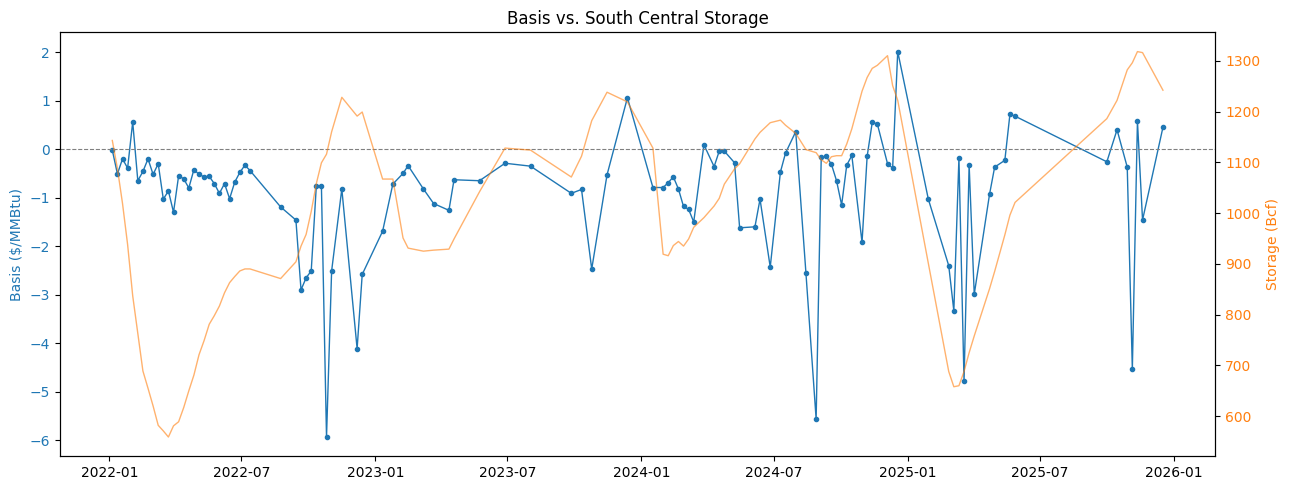

In [14]:
fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.plot(df_enriched["report_date"], df_enriched["basis_calculated"], color="tab:blue",
         marker="o", markersize=3, linewidth=1, label="Waha − Henry Hub basis")
ax1.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax1.set_ylabel("Basis ($/MMBtu)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(df_enriched["report_date"], df_enriched["storage_bcf"], color="tab:orange",
         linewidth=1, alpha=0.6, label="South Central storage (Bcf)")
ax2.set_ylabel("Storage (Bcf)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax1.set_title("Basis vs. South Central Storage")
fig.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/basis_vs_storage_chart.png", dpi=150)
plt.show()


In [15]:
df_enriched.to_csv(f"{PROCESSED_DIR}/basis_table_enriched.csv", index=False)
print(f"Saved {len(df_enriched)} rows to {PROCESSED_DIR}/basis_table_enriched.csv")


Saved 111 rows to ../data/processed/basis_table_enriched.csv
